In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


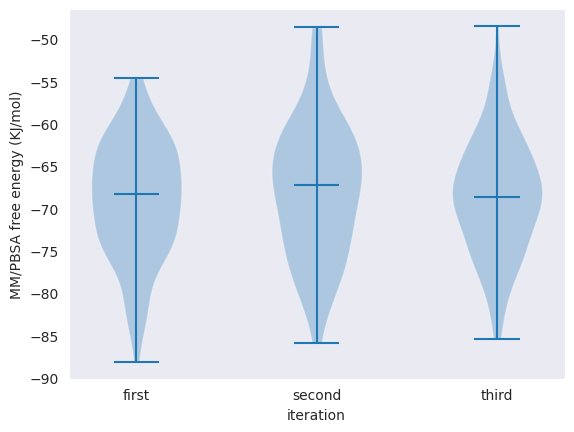

In [3]:
first = pd.read_csv("/home/kunzj/report/data/first_df_metrics_md_sim.csv")
second = pd.read_csv("/home/kunzj/report/data/second_df_metrics_md_sim.csv")
third = pd.read_csv("/home/kunzj/report/data/third_df_metrics_md_sim.csv")

plt.violinplot([first.mmpbsa,second.mmpbsa,third.mmpbsa], showmedians = True)
plt.grid(False)
plt.xticks([1,2,3],["first", "second", "third"],rotation=0)
plt.xlabel("iteration")
plt.ylabel("MM/PBSA free energy (KJ/mol)")


plt.show()

In [4]:
print(first.sort_values(by="mmpbsa"))

    Unnamed: 0       bsa  rmsd_mean  rmsd_std     hbond   sbridge     mmpbsa
90          91 -1.110390   0.207757  0.033898  6.093286  1.000000 -88.165778
23          24 -1.498390   0.331352  0.044747  7.051363  1.214224 -84.179333
89          90 -1.086878   0.228198  0.020438  4.577829  1.000000 -83.950889
59          60 -1.018049   0.235298  0.030744  5.813401  1.422198 -83.507333
47          48 -1.009049   0.229179  0.023081  5.044663  1.609740 -81.946889
..         ...       ...        ...       ...       ...       ...        ...
49          50 -1.318561   0.641489  0.181132  1.590651  0.857143 -58.633778
55          56 -0.982878   0.304537  0.056675  2.046055  0.749943 -57.064000
33          34 -1.730634   0.273567  0.048762  2.460021  0.000000 -56.923556
93          94 -0.890073   0.147864  0.033161  2.353297  1.216216 -55.455556
97          98 -1.250439   0.342190  0.078406  2.459585  1.000000 -54.654444

[102 rows x 7 columns]


In [5]:
import os
import re
def extract_chain_b_sequence(pdb_file_path):
    """
    /home/kunzj/BindCraft_uva_internship/data/sequences/first/
    Parses a PDB file to extract the amino acid sequence of Chain B.

    Returns:
        str: A string of three-letter amino acid codes separated by spaces.
    """
    amino_acids = []
    last_residue_id = None

    # Standard 3-to-1 mapping if a single-letter string is required:
    # d_map = {'GLN':'Q', 'PRO':'P', 'ARG':'R', 'GLY':'G', ...}

    try:
        with open(pdb_file_path, 'r') as f:
            for line in f:
                # ATOM records contain the coordinate and residue data
                if line.startswith("ATOM"):
                    chain_id = line[21].strip()
                    res_name = line[17:20].strip()
                    res_seq_num = line[22:26].strip()

                    # Filter for Chain B and ensure we only count each residue once
                    if chain_id == 'B':
                        if res_seq_num != last_residue_id:
                            amino_acids.append(res_name)
                            last_residue_id = res_seq_num

                # Stop if a TER record or ENDMDL is reached for the chain
                elif line.startswith("TER") and last_residue_id is not None:
                    # If the file contains multiple chains, we only want Chain B
                    # If Chain B is already processed, we can exit
                    if len(amino_acids) > 0:
                        break

        return amino_acids

    except FileNotFoundError:
        return "File not found."
def get_all_seq(directory_path):
    seqlist = []

    # Retrieve filenames from the directory
    filenames = os.listdir(directory_path)

    # Sort filenames numerically by extracting the leading integer
    # This regex matches one or more digits at the start of the string
    filenames.sort(key=lambda f: int(re.match(r'\d+', f).group()) if re.match(r'\d+', f) else float('inf'))

    for filename in filenames:
        file_path = os.path.join(directory_path, filename)

        if os.path.isfile(file_path):
            seqlist.append(extract_chain_b_sequence(file_path))
            print(file_path)

    return seqlist
sequences_2  = get_all_seq("/home/kunzj/BindCraft_uva_internship/data/sequences/second/")
lengths_2 = [*map(len, sequences_2)]
sequences_1  = get_all_seq("/home/kunzj/BindCraft_uva_internship/data/sequences/first/")
lengths_1 = [*map(len, sequences_1)]
first["length"] = lengths_1

/home/kunzj/BindCraft_uva_internship/data/sequences/second/1_BAX_1F16_l13_s142369_mpnn1_model1.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/second/2_BAX_1F16_l12_s508128_mpnn1_model1.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/second/3_BAX_1F16_l13_s142369_mpnn3_model1.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/second/4_BAX_1F16_l12_s664449_mpnn2_model2.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/second/5_BAX_1F16_l14_s704143_mpnn1_model1.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/second/6_BAX_1F16_l14_s704143_mpnn2_model1.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/second/7_BAX_1F16_l12_s411647_mpnn1_model1.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/second/8_BAX_1F16_l15_s960805_mpnn2_model1.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/second/9_BAX_1F16_l15_s960805_mpnn1_model1.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/second/10_BAX_1F16_l15_s395094_mpnn5_model1.pdb
/home/kun

In [6]:
second = second.rename(columns={"Unnamed: 0" : "Ranking"})
first = first.rename(columns={"Unnamed: 0" : "Ranking"})
df_all = pd.concat([first, second])

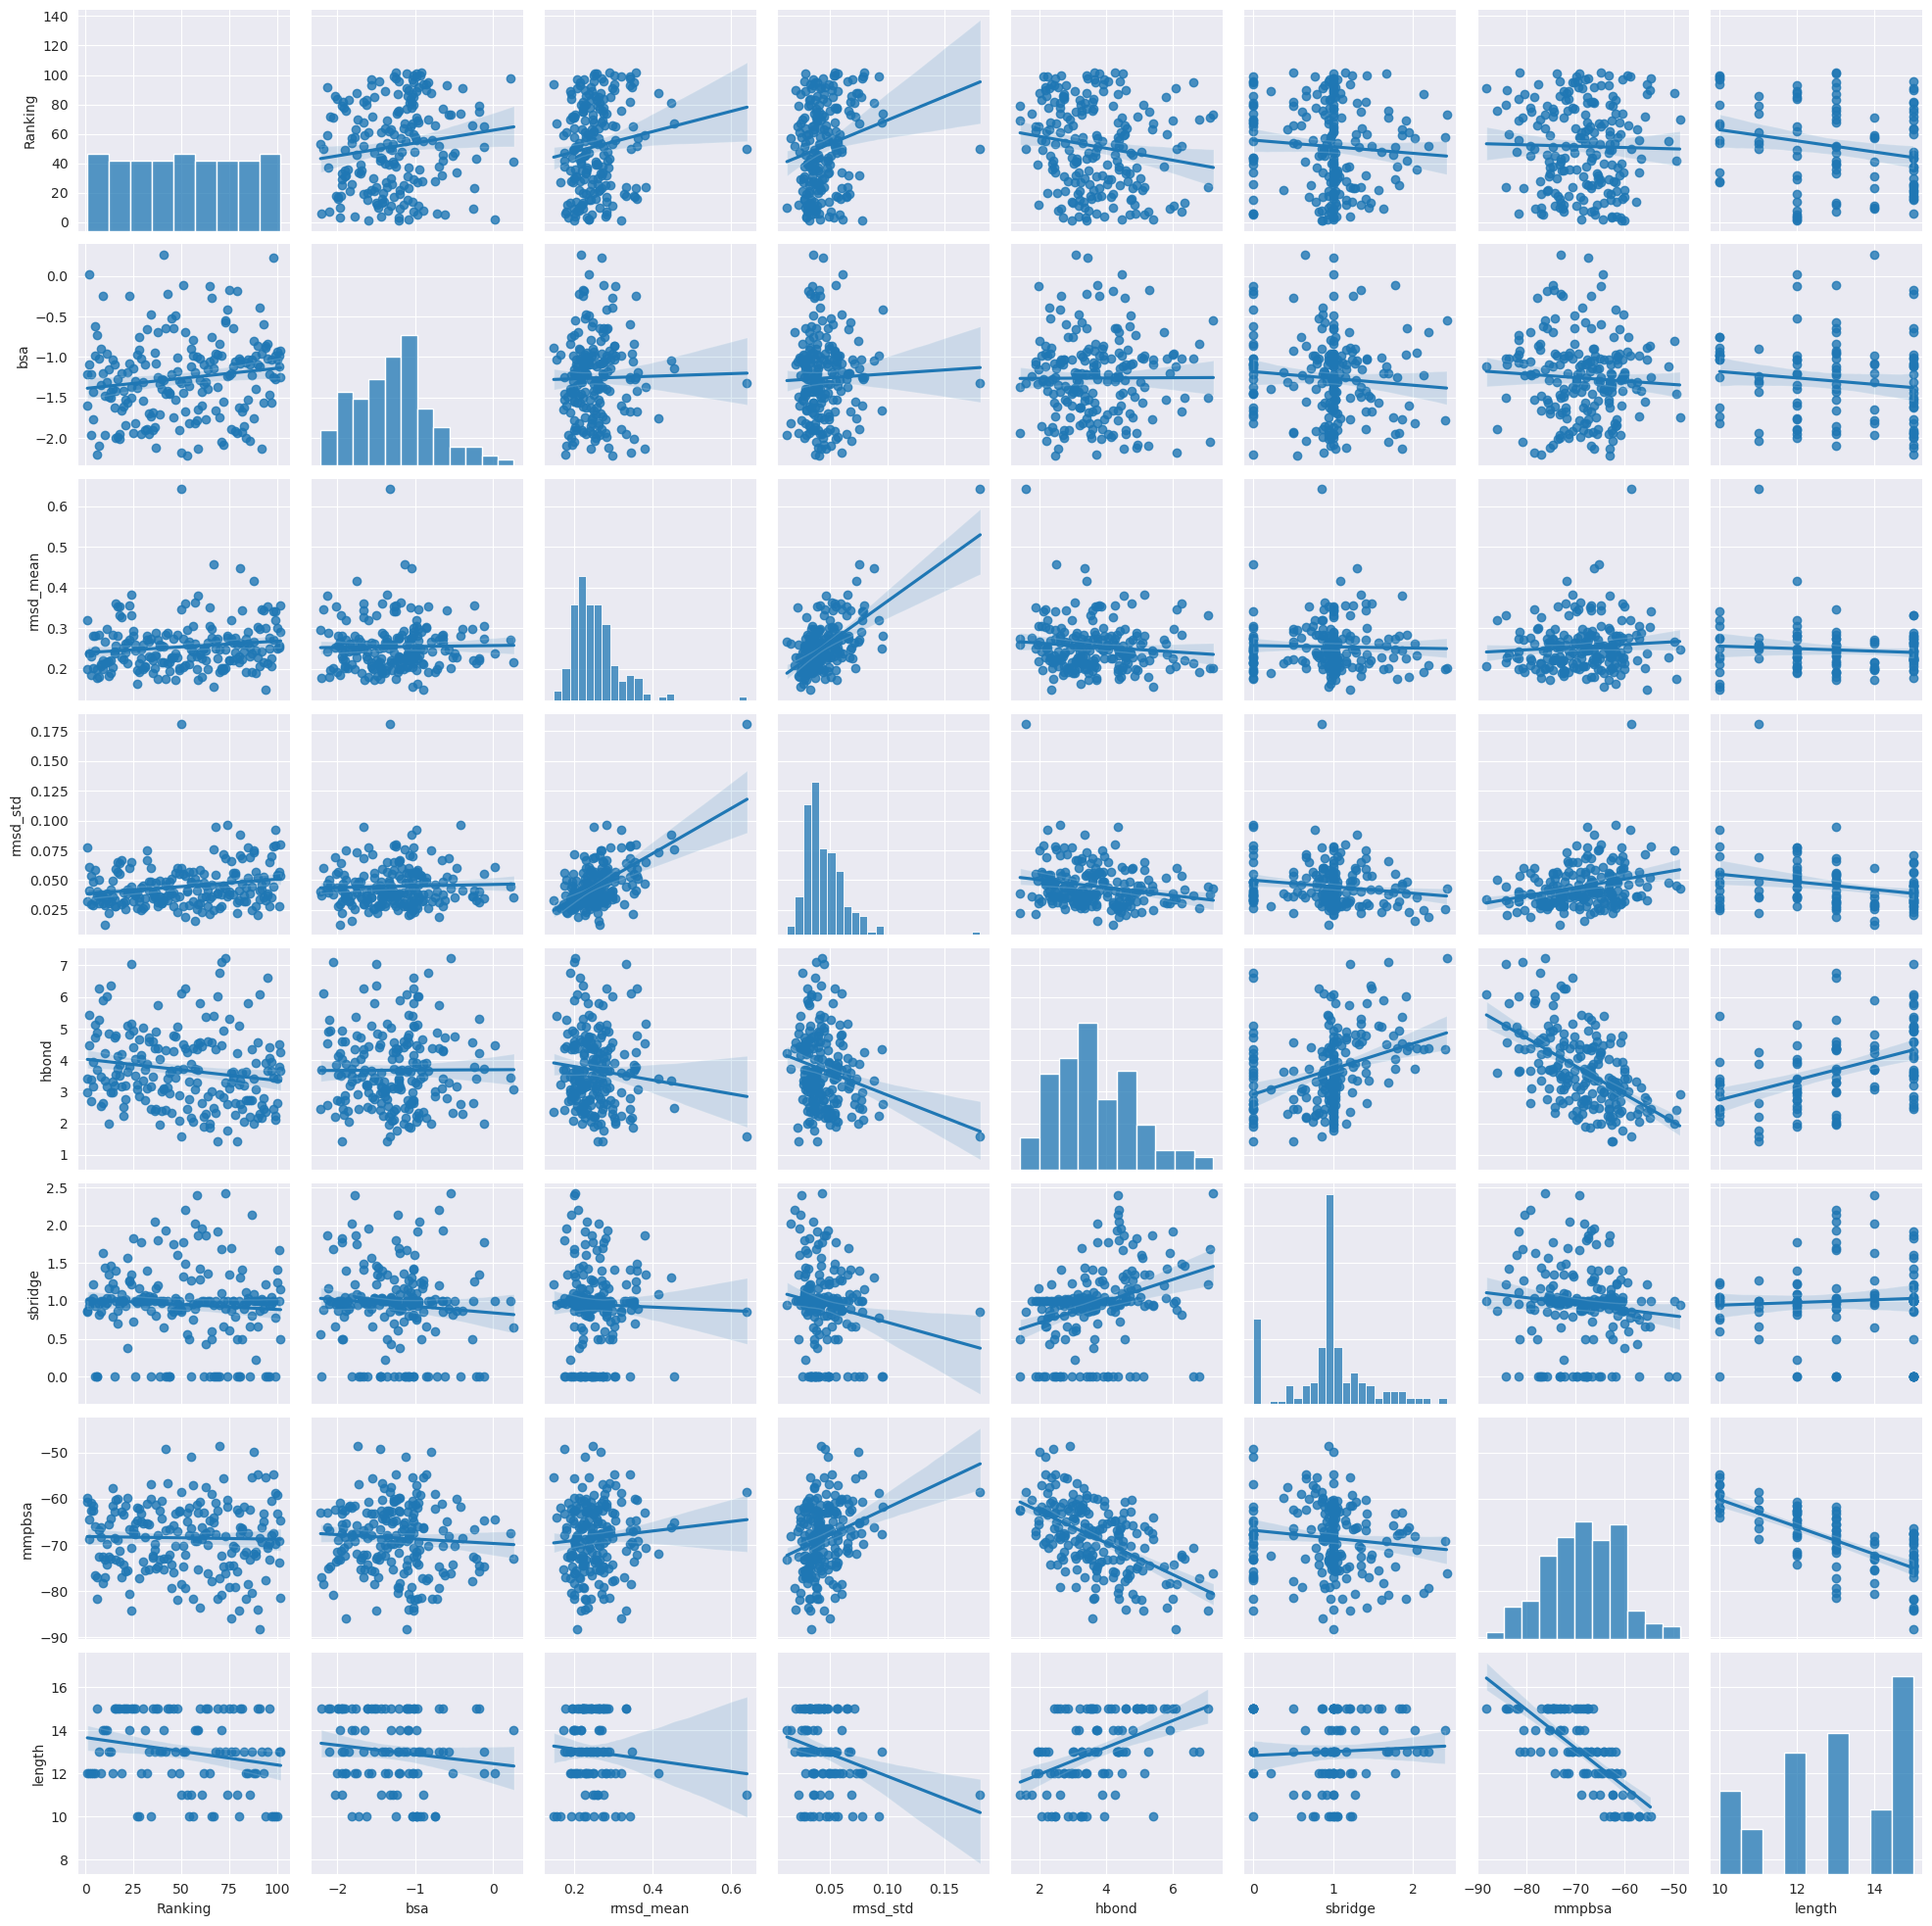

In [7]:

sns.pairplot(df_all, kind = "reg")


In [8]:
df_corr = df_all.corr()


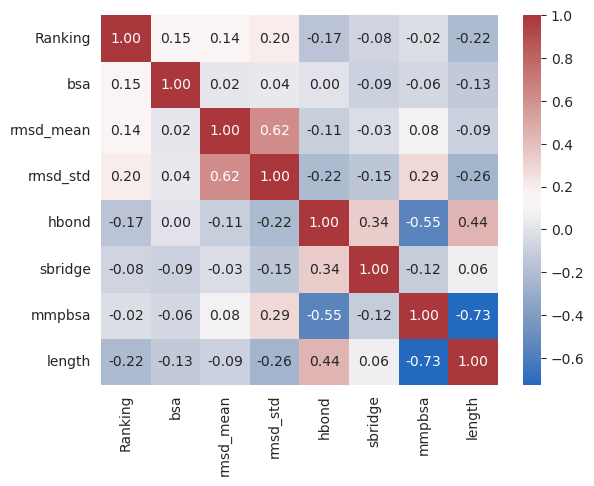

In [9]:
sns.heatmap(df_corr, annot=True, cmap='vlag', fmt='.2f')
plt.show()